# UTS IF5171 Bagian 2 - Deep Learning
___
Name: Arief Purnama Muharram<br>
NIM: 23521013

## Step 0: Prerequisites
___

### 0.1: Mount Google Drive

In [ ]:
from google.colab import drive


drive.mount('/content/drive/')

Mounted at /content/drive/


### 0.2: Install required packages

In [ ]:
!pip install numpy
!pip install tqdm
!pip install seaborn
!pip install torch
!pip install torchvision

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import tqdm
import seaborn as sns
import torch
import torchvision


print('NumPy version:', np.__version__)
print('Tqdm version:', tqdm.__version__)
print('Seaborn version:', sns.__version__)
print('Torch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)

NumPy version: 1.21.6
Tqdm version: 4.64.1
Seaborn version: 0.11.2
Torch version: 1.12.1+cu113
Torchvision version: 0.13.1+cu113


### 0.3: Predefined helper class

#### A: TrainUtils class

In [ ]:
import torch
from torch import nn
from torch import optim
from tqdm import tqdm


class TrainUtils:
  def __init__(self, model, loss_fn, optimizer, learning_rate=1e-3, device=None):
    super(TrainUtils, self).__init__()
    # Supported loss function
    self.supported_loss_fn = ['CrossEntropyLoss']
    # Supported optimizer
    self.supported_optim = ['SGD', 'Adam']
    # Learning rate
    self.learning_rate = learning_rate
    # Set model
    self.model = model
    # Set loss function
    if loss_fn not in self.supported_loss_fn:
      raise ValueError('Loss function is not supported!')
    else:
      if loss_fn == 'CrossEntropyLoss':
        self.loss_fn = nn.CrossEntropyLoss()
      else:
        self.loss_fn = None
    # Set optimizer
    if optimizer not in self.supported_optim:
      raise ValueError('Optimizer is not supported!')
    else:
      if optimizer == 'SGD':
        self.optimizer = optim.SGD(
            model.parameters(),
            lr = self.learning_rate
        )
      elif optimizer == 'Adam':
        self.optimizer = optim.Adam(
            model.parameters(),
            lr = self.learning_rate
        )
      else:
        self.optimizer = None
    if device is not None:
      self.device = device
    else:
      if torch.cuda.is_available():
        self.device = 'cuda'
        gpu_info = !nvidia-smi
        gpu_info = '\n'.join(gpu_info)
        print('Using NVidia Cuda!')
        print(gpu_info, '\n')
      else:
        self.device = 'cpu'
        print('Using CPU!\n')
  
  def set_model(self, model):
    self.model = model
  
  def set_loss_fn(self, loss_fn):
    if loss_fn not in self.supported_loss_fn:
      raise ValueError('Loss function is not supported!')
    else:
      if loss_fn == 'CrossEntropyLoss':
        self.loss_fn = nn.CrossEntropyLoss()
      else:
        self.loss_fn = None
  
  def set_optimizer(self, optimizer):
    if optimizer not in self.supported_optim:
      raise ValueError('Optimizer is not supported!')
    else:
      if optimizer == 'SGD':
        self.optimizer = optim.SGD(
            self.model.parameters(),
            lr = self.learning_rate
        )
      elif optimizer == 'Adam':
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr = self.learning_rate
        )
      else:
        self.optimizer = None
  
  def set_learning_rate(self, learning_rate):
    self.learning_rate = learning_rate

  def train(self, train_dataloader, print_log=False):
    model = self.model
    loss_fn = self.loss_fn
    optimizer = self.optimizer
    device = self.device
    loss_history = []
    for batch, (X, y) in enumerate(tqdm(train_dataloader)):
      # Switch to train mode
      model.train()
      X, y, model = X.to(device), y.to(device), model.to(device)
      # Compute error
      pred = model(X)
      loss = loss_fn(pred, y)
      # Backpropagation
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if batch % 100 == 0:
        loss_history.append([batch, loss])
    if print_log == True:
      print('Loss over batches:')
      print(' Batch\tLoss')
      for item in loss_history:
        print(f' {item[0]}\t{item[1]:>7f}')
    return (loss_history)

  def test(self, dataloader, print_log=False):
    model = self.model
    loss_fn = self.loss_fn
    device = self.device
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
      for X, y in dataloader:
        X, y, model = X.to(device), y.to(device), model.to(device)
        pred = model(X)
        test_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    if print_log == True:
      print(f'Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f}')
    return (correct)

#### B: Models class

##### B.1: MLP model

In [ ]:
from torch import nn


class MLP(nn.Module):
  def __init__(self, d_out=10):
    super(MLP, self).__init__()
    self.flatten = nn.Flatten()
    self.network = nn.Sequential(
        nn.LazyLinear(512),
        nn.ReLU(),
        nn.LazyLinear(512),
        nn.ReLU(),
        nn.LazyLinear(d_out)
    )
  
  def forward(self, x):
    x = self.flatten(x)
    logits = self.network(x)
    return logits

##### B.2: ConvNet model

In [ ]:
from torch import nn


class ConvNet(nn.Module):
  def __init__(self, d_out=10):
    super(ConvNet, self).__init__()
    self.conv1 = nn.LazyConv2d(out_channels=32, kernel_size=3)
    self.conv2 = nn.LazyConv2d(out_channels=32, kernel_size=3)
    self.max_pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.conv3 = nn.LazyConv2d(out_channels=64, kernel_size=3)
    self.conv4 = nn.LazyConv2d(out_channels=64, kernel_size=3)
    self.max_pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

    self.fc1 = nn.LazyLinear(512)
    self.relu1 = nn.ReLU()
    self.fc2 = nn.LazyLinear(d_out)
  
  def forward(self, x):
    out = self.conv1(x)
    out = self.conv2(out)
    out = self.max_pool1(out)

    out = self.conv3(out)
    out = self.conv4(out)
    out = self.max_pool2(out)

    out = out.reshape(out.size(0), -1)

    out = self.fc1(out)
    out = self.relu1(out)
    out = self.fc2(out)
    return out

##### B.3: ResNet18 model

In [ ]:
import torch.nn as nn
from torchvision.models import resnet18

### 0.4: Define constants

In [ ]:
import os


GDRIVE_DIR = '/content/drive/MyDrive/IF5171-UTS/'
DATA_DIR = 'data'
MODEL_DIR = 'models'
LOG_DIR = 'logs'
FIGURE_DIR = 'figures'

EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

## Step 1: Load Dataset
___

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms as T

In [ ]:
training_data = datasets.CIFAR100(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=T.Compose([
        T.RandomCrop(32, padding=4,padding_mode='reflect'),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
)

test_data = datasets.CIFAR100(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=T.Compose([
        T.ToTensor(),
        T.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
)

  0%|          | 0/169001437 [00:00<?, ?it/s]

Extracting data/cifar-100-python.tar.gz to data
Files already downloaded and verified


In [ ]:
from sklearn.model_selection import train_test_split


training_data, validation_data = train_test_split(
    training_data, test_size=0.33
)

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE)
validation_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE)

## Step 2: Model Training
___

### 2.1: Train wrapper

In [ ]:
import os
import time as timer
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def train_wrapper(model, trainer, 
                  train_dataloader, validation_dataloader, test_dataloader, 
                  epochs=10, saved_model_name='model.pth', log_name='log.txt'):
  model_path = os.path.join(GDRIVE_DIR, MODEL_DIR)
  log_path = os.path.join(GDRIVE_DIR, LOG_DIR)
  figure_path = os.path.join(GDRIVE_DIR, FIGURE_DIR)

  if not os.path.exists(model_path):
    os.makedirs(model_path)
  if not os.path.exists(log_path):
    os.makedirs(log_path)
  if not os.path.exists(figure_path):
    os.makedirs(figure_path)

  model_path = os.path.join(model_path, saved_model_name)
  log_path = os.path.join(log_path, log_name)

  train_history = []

  with open(log_path, 'a') as fh:
    fh.write('epoch\ttrain_acc\ttest_acc\n')
    for epoch in range(epochs):
      print(f"Epoch {epoch+1} out of {epochs}\n------------------")
      start = timer.time()
      # Train model
      trainer.train(train_dataloader, print_log=False)  
      elapsed_time = timer.time() - start
      print(f"Training time: {elapsed_time:>.2f} seconds")
      # Evaluate model: get training accuracy 
      training_accuracy = trainer.test(validation_dataloader, print_log=False)
      # Evaluate model: get testing accuracy
      testing_accuracy = trainer.test(test_dataloader, print_log=False)
      # Append history
      train_history.append([epoch, training_accuracy, testing_accuracy])
      # Write log
      fh.write(f'{epoch}\t{training_accuracy}\t{testing_accuracy}\n')
      # Save model
      torch.save(model.state_dict(), model_path)
      print(f"Model {model_path} stored!\n")
  
  train_history = pd.DataFrame(train_history, columns=['epoch', 'train_acc', 'test_acc'])

  # Plot accurcy
  plt.figure()
  train_history.drop(columns=['epoch']).plot.line()
  plt.title(f'{saved_model_name} Accuracy History over Epochs\n', fontdict={
      'fontsize': 15, 'fontweight': 'bold'
  })
  plt.xlabel('Epoch', fontdict={
      'fontsize': 10
  })
  plt.ylabel('Accuracy', fontdict={
      'fontsize': 10
  })

  # Save figure
  figure_name = saved_model_name.split('.')[0]
  figure_name = f'{figure_name}.png'
  figure_name = os.path.join(figure_path, figure_name)
  plt.savefig(figure_name)

  # Show plot
  plt.show()

  print("Done!")

### 2.2: CIFAR-100

#### A: MLP classifier

##### A.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Mon Oct 10 10:21:30 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   39C    P8    10W /  70W |      3MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 524/524 [00:07<00:00, 72.56it/s] 


Training time: 7.23 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_mlp_sgd.pth stored!

Epoch 2 out of 80
------------------


100%|██████████| 524/524 [00:01<00:00, 518.70it/s]


...

100%|██████████| 524/524 [00:01<00:00, 507.49it/s]


Training time: 1.04 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_mlp_sgd.pth stored!

Epoch 80 out of 80
------------------


100%|██████████| 524/524 [00:00<00:00, 524.76it/s]


Training time: 1.01 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_mlp_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

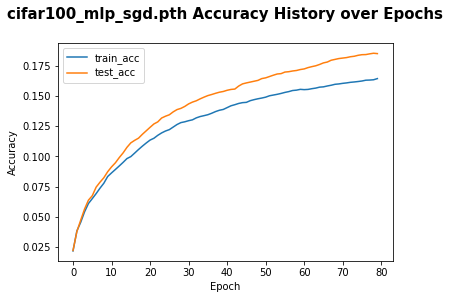

Done!


In [ ]:
model = MLP(d_out=100)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=80, saved_model_name='cifar100_mlp_sgd.pth', log_name='cifar100_mlp_sgd.txt')

##### A.2: Using ADAM optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Mon Oct 10 10:25:56 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   49C    P0    28W /  70W |    850MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 524/524 [00:01<00:00, 394.55it/s]


Training time: 1.34 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_mlp_adam.pth stored!

Epoch 2 out of 80
------------------


100%|██████████| 524/524 [00:01<00:00, 418.12it/s]


...

100%|██████████| 524/524 [00:01<00:00, 412.70it/s]


Training time: 1.28 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_mlp_adam.pth stored!

Epoch 80 out of 80
------------------


100%|██████████| 524/524 [00:01<00:00, 408.95it/s]


Training time: 1.29 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_mlp_adam.pth stored!



<Figure size 432x288 with 0 Axes>

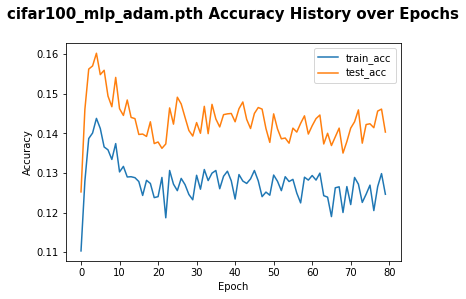

Done!


In [ ]:
model = MLP(d_out=100)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=80, saved_model_name='cifar100_mlp_adam.pth', log_name='cifar100_mlp_adam.txt')

#### B: ConvNet classifier

##### B.1: Using SGD optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Mon Oct 10 10:30:38 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   56C    P0    29W /  70W |    872MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 524/524 [00:06<00:00, 85.96it/s] 


Training time: 6.11 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_convnet_sgd.pth stored!

Epoch 2 out of 80
------------------


100%|██████████| 524/524 [00:02<00:00, 255.71it/s]


...

100%|██████████| 524/524 [00:02<00:00, 251.95it/s]


Training time: 2.09 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_convnet_sgd.pth stored!

Epoch 80 out of 80
------------------


100%|██████████| 524/524 [00:02<00:00, 253.66it/s]


Training time: 2.07 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_convnet_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

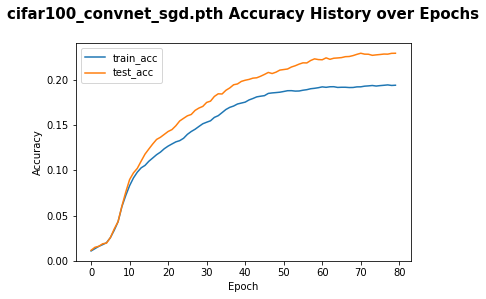

Done!


In [ ]:
model = ConvNet(d_out=100)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=80, saved_model_name='cifar100_convnet_sgd.pth', log_name='cifar100_convnet_sgd.txt')

##### B.2: Using Adam optimizer

/usr/local/lib/python3.7/dist-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


Using NVidia Cuda!
Mon Oct 10 10:36:57 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   67C    P0    31W /  70W |   1244MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 524/524 [00:02<00:00, 227.76it/s]


Training time: 2.31 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_convnet_adam.pth stored!

Epoch 2 out of 80
------------------


100%|██████████| 524/524 [00:02<00:00, 228.17it/s]


...

100%|██████████| 524/524 [00:02<00:00, 232.06it/s]


Training time: 2.26 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_convnet_adam.pth stored!

Epoch 80 out of 80
------------------


100%|██████████| 524/524 [00:02<00:00, 229.19it/s]


Training time: 2.30 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_convnet_adam.pth stored!



<Figure size 432x288 with 0 Axes>

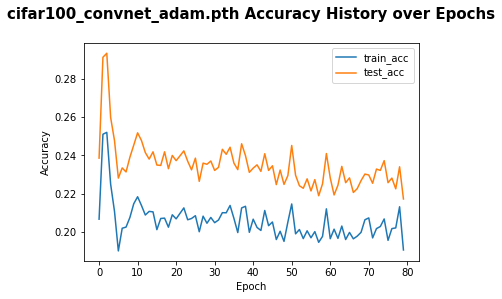

Done!


In [ ]:
model = ConvNet(d_out=100)
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=80, saved_model_name='cifar100_convnet_adam.pth', log_name='cifar100_convnet_adam.txt')

#### C: ResNet18 classifier

##### B.1: Using SGD optimizer

Using NVidia Cuda!
Mon Oct 10 10:43:21 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   68C    P0    31W /  70W |   1244MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 524/524 [00:08<00:00, 62.91it/s]


Training time: 8.34 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_resnet18_sgd.pth stored!

Epoch 2 out of 80
------------------


100%|██████████| 524/524 [00:07<00:00, 66.35it/s]


Training time: 7.90 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_resnet18_sgd.pth stored!

Epoch 3 out of 80
------------------


...

100%|██████████| 524/524 [00:08<00:00, 65.13it/s]


Training time: 8.07 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_resnet18_sgd.pth stored!

Epoch 80 out of 80
------------------


100%|██████████| 524/524 [00:08<00:00, 65.12it/s]


Training time: 8.07 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_resnet18_sgd.pth stored!



<Figure size 432x288 with 0 Axes>

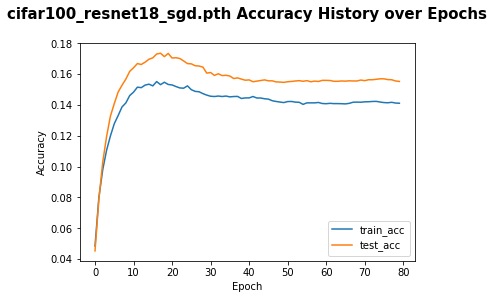

Done!


In [ ]:
model = resnet18()
trainer = TrainUtils(model, 'CrossEntropyLoss', 'SGD')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=80, saved_model_name='cifar100_resnet18_sgd.pth', log_name='cifar100_resnet18_sgd.txt')

##### B.2: Using Adam optimizer

Using NVidia Cuda!
Mon Oct 10 10:59:47 2022       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.32.03    Driver Version: 460.32.03    CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla T4            Off  | 00000000:00:04.0 Off |                    0 |
| N/A   72C    P0    32W /  70W |   1338MiB / 15109MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                     

100%|██████████| 524/524 [00:10<00:00, 51.98it/s]


Training time: 10.08 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_resnet18_adam.pth stored!

Epoch 2 out of 80
------------------


100%|██████████| 524/524 [00:10<00:00, 51.92it/s]


Training time: 10.10 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_resnet18_adam.pth stored!

Epoch 3 out of 80
------------------


...

100%|██████████| 524/524 [00:10<00:00, 52.08it/s]


Training time: 10.09 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_resnet18_adam.pth stored!

Epoch 80 out of 80
------------------


100%|██████████| 524/524 [00:10<00:00, 51.67it/s]


Training time: 10.17 seconds
Model /content/drive/MyDrive/IF5171-UTS/models/cifar100_resnet18_adam.pth stored!



<Figure size 432x288 with 0 Axes>

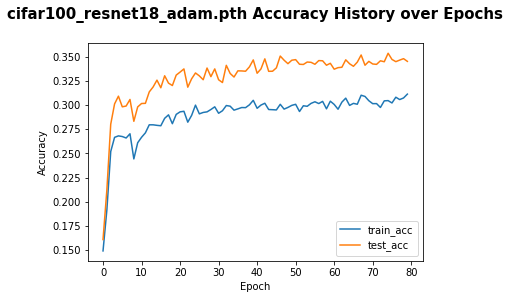

Done!


In [19]:
model = resnet18()
trainer = TrainUtils(model, 'CrossEntropyLoss', 'Adam')

train_wrapper(model, trainer,
              train_dataloader=train_dataloader, 
              validation_dataloader=validation_dataloader, 
              test_dataloader=test_dataloader,
              epochs=80, saved_model_name='cifar100_resnet18_adam.pth', log_name='cifar100_resnet18_adam.txt')

## Step 3: Conclusion
___

Best performance for 80 epochs training was achieved by using ResNet18 and Adam optimizer with the best accuracy up to 35% (0.350). Furthermore experiments are needed to improve the model accuracy. Several method to improve the model accuracy is by using dropout, batch normalization, or both of them in ResNet18 model using Adam optimizer.